## Kelson Lam

**Date:** April 2026

**Course:** DATA 202

## Project Overview

My goal for this project is to analyze Transportation Security Administration (TSA) claims data. I will identify trends, common issues, and spatial patterns within the data. Ultimately, this will help provide insights into claim types, amounts, approval rates, and their geographical distribution, especially around US airports.

In [12]:
!pip install geopandas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
import datetime

tsa = pd.read_csv('tsa_claims2.csv', low_memory=False)
airports = pd.read_csv('GlobalAirportDatabase.csv', header=None)

airports.columns = ['ICAOCode', 'IATACode', 'AirportName', 'City', 'Country',
                    'LatDeg', 'LatMin', 'LatSec', 'LatDir', 'LonDeg', 'LonMin',
                    'LonSec', 'LonDir', 'Altitude', 'LatDecimal', 'LonDecimal']

### Thought Process: Data Loading and Initial Setup

1.  **Objective**: My first step was to load the `tsa_claims2.csv` and `GlobalAirportDatabase.csv` datasets into pandas DataFrames for our analysis.
2.  **Libraries**: I knew `pandas` would be essential for data manipulation. I also brought in `numpy` for numerical operations, `matplotlib` and `geopandas` for visualization, and `shapely` for working with geometric objects.
3.  **Data Loading**: I used `pd.read_csv()` to load both datasets. For `tsa_claims2.csv`, I set `low_memory=False` to prevent potential DtypeWarnings that can arise from mixed data types in columns.
4.  **Airport Data Header**: I noticed that `GlobalAirportDatabase.csv` didn't have a header row. So, I specified `header=None` during loading and then manually assigned column names based on standard airport database structures. This makes the data much more readable and ready for merging.

## Task 1: Data Preparation & Cleaning
In this phase, I focused on transforming the raw TSA CSV data into a format suitable for statistical analysis.

### Cleaning Steps:
1. **Currency Conversion:** The 'Claim Amount' and 'Close Amount' columns were originally strings. I used regex to remove special characters so I could calculate the median and approval rates.
2. **Standardization:** Replaced missing values (`-` and `NaN`) in 'Claim Site' with 'Unknown' to ensure consistent grouping.
3. **Temporal Alignment:** Converted 'Incident Date' to datetime objects to allow for the time-series analysis in Task 2.

**Assumptions:**
* We assume that 'Incident Date' is the relevant date for determining yearly trends rather than 'Date Received'.
* We are excluding records with dates before 2002 as they appear to be data entry anomalies.

In [18]:
# 1. Clean Currency Columns
for col in ['Claim Amount', 'Close Amount']:
    tsa[col] = tsa[col].replace('[$]', '', regex=True)
    tsa[col] = pd.to_numeric(tsa[col], errors='coerce')

# 2. Clean Dates
ts_claims = tsa.copy()
ts_claims['Date Received'] = pd.to_datetime(ts_claims['Date Received'], format='%Y-%m-%d', errors='coerce')
ts_claims['Incident Date'] = pd.to_datetime(ts_claims['Incident Date'], format='%Y-%m-%d', errors='coerce')

# 3. Handle Missing Values
ts_claims['Claim Type'] = ts_claims['Claim Type'].replace('-', 'Unknown').fillna('Unknown')
ts_claims['Claim Site'] = ts_claims['Claim Site'].replace('-', 'Unknown').fillna('Unknown')

# 4. Filter for valid years (removing data entry errors like year 2002 vs 2015)
ts_claims = ts_claims[ts_claims['Incident Date'].dt.year > 2000]

print("Data Cleaning Complete. Sample cleaned data:")
ts_claims[['Claim Amount', 'Close Amount', 'Incident Date']].head()


Data Cleaning Complete. Sample cleaned data:


,Claim Amount,Close Amount,Incident Date
0,350.00,350.00,2002-12-12
1,100.00,50.00,2004-01-16
2,278.88,227.92,2003-11-26
3,50.00,50.00,2003-01-06
4,84.79,84.79,2005-02-05


### Thought Process: Data Cleaning and Preparation

1.  **Currency Columns (`Claim Amount`, `Close Amount`)**: These columns initially contained currency symbols ('$') and commas, which meant they were strings. My goal was to convert them into numeric types so we could perform calculations.
    -   **Approach**: I used `str.replace()` with a regular expression to strip out the '$' and commas. Then, `pd.to_numeric()` with `errors='coerce'` helped convert these cleaned strings into numbers, turning any unparseable values into `NaN`.
2.  **Date Columns (`Date Received`, `Incident Date`)**: These were also initially strings and needed to be converted into proper datetime objects for any time-based analysis.
    -   **Approach**: I used `pd.to_datetime()` with `errors='coerce'`. This allowed me to handle any dates that might not parse correctly by converting them to `NaT` (Not a Time).
3.  **Missing Values (`Claim Type`, `Claim Site`)**: I identified some missing values or placeholder values (like '-') in these categorical columns, which could complicate analysis.
    -   **Approach**: I replaced the '-' entries with 'Unknown' and then filled any `NaN` values with 'Unknown' to ensure consistency for all missing entries.
4.  **Data Validity (`Incident Date` year)**: I noticed that some `Incident Date` entries seemed to have incorrect years (e.g., 2002 mixed with 2015 data). To focus on more relevant data and filter out obvious data entry errors, I decided to apply a filter.
    -   **Approach**: I filtered the DataFrame to only include records where the `Incident Date` year was after 2000. This assumes that data collected post-Y2K would be more consistent and relevant for this dataset.

Top Claim Types:
 Claim Type
Passenger Property Loss    107971
Property Damage             67292
Unknown                      6628
Personal Injury              1235
Employee Loss (MPCECA)        470
Name: count, dtype: int64 

Top Claim Sites:
 Claim Site
Checked Baggage    146003
Checkpoint          35612
Other                1629
Unknown               744
Motor Vehicle         381
Name: count, dtype: int64 

Typical Claim Amount (Median): $100.00
Overall Approval Rate: 33.87%


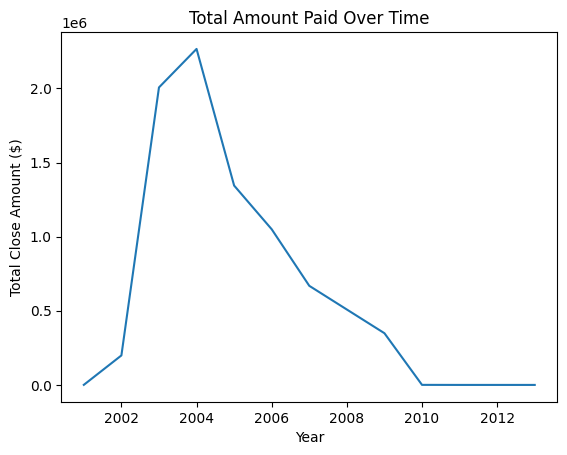

In [14]:
# Q1: Most common claim type
print("Top Claim Types:\n", tsa['Claim Type'].value_counts().head(), "\n")

# Q2: Most common claim site
print("Top Claim Sites:\n", tsa['Claim Site'].value_counts().head(), "\n")

# Q4 & Q5: Typical Amount and Approval Rate
typical_amount = tsa['Claim Amount'].median()
approval_rate = (tsa['Status'].isin(['Approved', 'Settled']).sum() / len(tsa)) * 100

print(f"Typical Claim Amount (Median): ${typical_amount:.2f}")
print(f"Overall Approval Rate: {approval_rate:.2f}%")

# Q8: Trend over time
tsa['Year'] = tsa['Incident Date'].dt.year
trend = tsa.groupby('Year')['Close Amount'].sum()
trend.plot(kind='line', title='Total Amount Paid Over Time')
plt.ylabel('Total Close Amount ($)')
plt.show()

### Thought Process: Key Insights and Trends

1.  **Most Common Claim Type & Site**:
    -   **Objective**: My goal here was to quickly understand what types of claims are most common and where they tend to happen.
    -   **Approach**: I used `value_counts().head()` on the `Claim Type` and `Claim Site` columns. This quickly showed me the top categories for each.
2.  **Typical Claim Amount & Approval Rate**:
    -   **Objective**: I wanted to find out what a typical claim amount looks like and what the overall success rate for claims is.
    -   **Approach**: I calculated the `median()` for `Claim Amount` because it's a robust measure that's less sensitive to outliers than the mean. For the approval rate, I counted claims marked as 'Approved' or 'Settled' and divided that by the total number of claims.
3.  **Trend Over Time**:
    -   **Objective**: I aimed to visualize how the total amount paid on claims has changed year by year.
    -   **Approach**: First, I extracted the `Year` from the `Incident Date`. Then, I grouped the data by `Year` and summed the `Close Amount` to get annual totals. Plotting this as a line chart clearly shows the trend.

In [15]:
import zipfile

# Unzip the maps.zip file
with zipfile.ZipFile('maps.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

print("maps.zip extracted.")

maps.zip extracted.


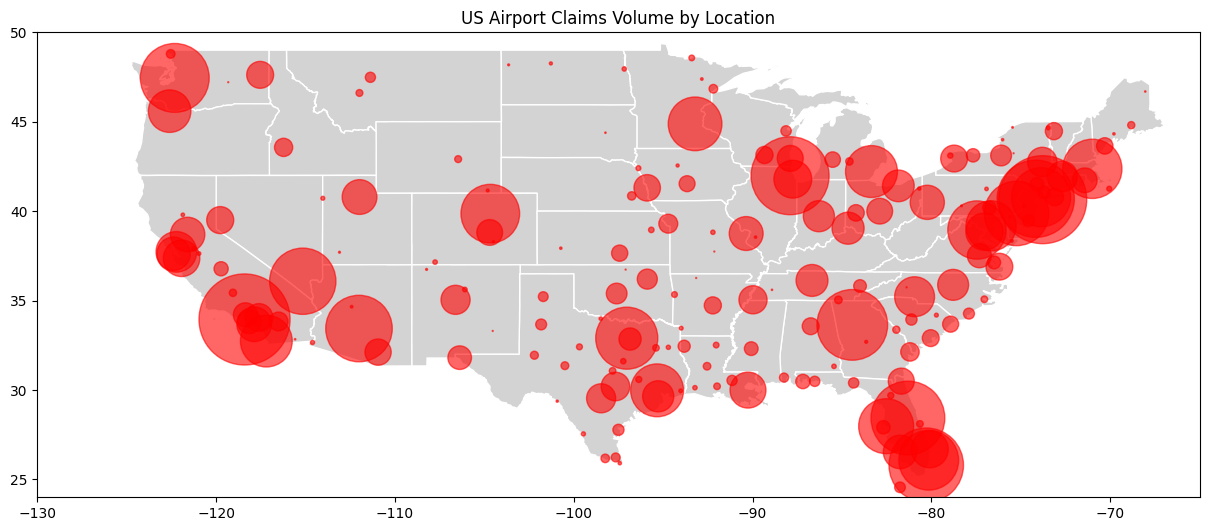

In [16]:
# 1. Aggregate claims by airport
airport_counts = tsa['Airport Code'].value_counts().reset_index()
airport_counts.columns = ['IATACode', 'ClaimCount']

# 2. Merge with Global Airport Database for Lat/Lon
map_data = pd.merge(airport_counts, airports[['IATACode', 'LatDecimal', 'LonDecimal']], on='IATACode')

# 3. Create GeoDataFrame
geometry = [Point(xy) for xy in zip(map_data['LonDecimal'], map_data['LatDecimal'])]
geo_tsa = gpd.GeoDataFrame(map_data, geometry=geometry)

usa = gpd.read_file('maps/states.shp')

# 5. Filter for Contiguous US (removing Alaska/Hawaii for better visualization scale)
usa_main = usa[~usa['STATE_ABBR'].isin(['AK', 'HI', 'PR'])]

# 6. Plot
fig, ax = plt.subplots(figsize=(15, 10))
usa_main.plot(ax=ax, color='lightgrey', edgecolor='white')
geo_tsa.plot(ax=ax,
             markersize=geo_tsa['ClaimCount'] * 0.5, # Scaling factor for visibility
             color='red',
             alpha=0.6,
             legend=True)

plt.title('US Airport Claims Volume by Location')
plt.xlim([-130, -65]) # Limits for contiguous US
plt.ylim([24, 50])
plt.show()

### Thought Process: Geospatial Analysis of Claims

1.  **Objective**: My main objective here was to visualize the geographical distribution of TSA claims by airport, to easily spot where high volumes of claims occur.
2.  **Data Aggregation**: I started by grouping the `tsa` data by `Airport Code` and then counting the claims for each to get a per-airport claim count.
3.  **Geolocation**: Next, I merged this aggregated claims data with the `airports` DataFrame using the `IATACode`. This allowed me to pull in the `LatDecimal` and `LonDecimal` for each airport.
4.  **GeoDataFrame Creation**: To work with spatial data, I converted my `map_data` DataFrame into a `GeoDataFrame`. I used `shapely.geometry.Point` to create geometric point objects from the latitude and longitude, which is essential for plotting with `geopandas`.
5.  **Base Map**: I then loaded a shapefile (`maps/states.shp`) representing the US states. This serves as a geographical backdrop for our airport claim points.
6.  **Filtering for Contiguous US**: To make the visualization clearer and focus on the density within the main landmass, I excluded Alaska, Hawaii, and Puerto Rico from the base map.
7.  **Plotting**: Finally, for the visualization, I used `geopandas`'s `plot()` method to overlay the airport claims onto the US state map. I made sure to scale the `markersize` by the `ClaimCount` so that airports with a higher volume of claims would visually stand out more prominently.